# Load Pacakges

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

OUTPUT_DIR = "outputs/"
import os; os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load Data

In [3]:
orders = pd.read_csv("data/raw/olist_orders_dataset.csv", parse_dates=[
             "order_purchase_timestamp",
             "order_approved_at",
             "order_delivered_carrier_date",
             "order_delivered_customer_date",
             "order_estimated_delivery_date"])

reviews = pd.read_csv("data/raw/olist_order_reviews_dataset.csv",
              parse_dates=["review_creation_date", "review_answer_timestamp"])

items    = pd.read_csv("data/raw/olist_order_items_dataset.csv")

payments = pd.read_csv("data/raw/olist_order_payments_dataset.csv")

customers= pd.read_csv("data/raw/olist_customers_dataset.csv")

products = pd.read_csv("data/raw/olist_products_dataset.csv")

cat_map  = pd.read_csv("data/raw/product_category_name_translation.csv")

name_map = dict(zip(cat_map["product_category_name"],
                    cat_map["product_category_name_english"]))

products = products.merge(cat_map, on="product_category_name", how="left")

rev = (reviews.sort_values("review_score")
       .drop_duplicates("order_id", keep="first")
       [["order_id", "review_score", "review_creation_date"]])

pay = (payments.groupby("order_id")
       .agg(total_value=("payment_value","sum")).reset_index())

df = (orders
      .merge(customers[["customer_id","customer_unique_id","customer_state"]], on="customer_id", how="left")
      .merge(rev,  on="order_id", how="left")
      .merge(pay,  on="order_id", how="left"))

df["is_return"] = (
    (df["order_status"] == "delivered") & (df["review_score"] <= 2)
).astype(int)

df["days_to_review"] = (
    df["review_creation_date"] - df["order_delivered_customer_date"]
).dt.days
df["days_to_review"] = df["days_to_review"].where(df["days_to_review"] >= 0).clip(upper=90)

overall_rate = df.loc[df["order_status"] == "delivered", "is_return"].mean()
print(f"Loaded {len(df):,} orders — return proxy rate: {overall_rate*100:.1f}%\n")

Loaded 99,441 orders — return proxy rate: 12.8%



In [4]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,review_score,review_creation_date,total_value,is_return,days_to_review
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,SP,4.0,2017-10-11,38.71,0,0.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,BA,4.0,2018-08-08,141.46,0,0.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,GO,5.0,2018-08-18,179.12,0,0.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,RN,5.0,2017-12-03,72.20,0,0.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,SP,5.0,2018-02-17,28.62,0,0.0


# EDA

## PLOT 1 — Review score histogram

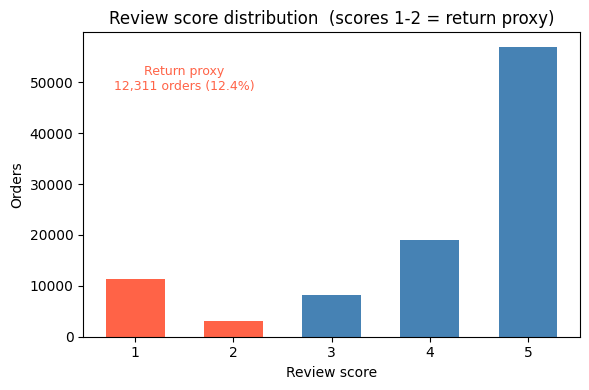

plot1_review_scores.png saved


In [5]:
score_counts = df["review_score"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(score_counts.index, score_counts.values, color="steelblue", width=0.6)

# Highlight return proxy scores
for score in [1, 2]:
    if score in score_counts.index:
        ax.bar(score, score_counts[score], color="tomato", width=0.6)

ax.set_xlabel("Review score")
ax.set_ylabel("Orders")
ax.set_title("Review score distribution  (scores 1-2 = return proxy)")
ax.set_xticks([1, 2, 3, 4, 5])
ax.text(1.5, score_counts.max() * 0.85,
        f"Return proxy\n{df['is_return'].sum():,} orders ({df['is_return'].mean()*100:.1f}%)",
        ha="center", fontsize=9, color="tomato")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}plot1_review_scores.png", dpi=150)
plt.show()
print("plot1_review_scores.png saved")

## PLOT 2 — Return rate by product category (top 15)

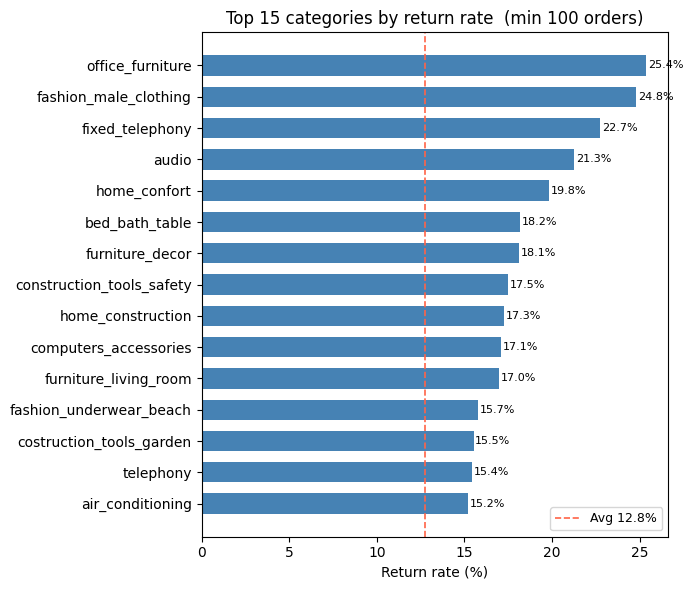

In [6]:
orders_items = (df[df["order_status"] == "delivered"]
    .merge(items[["order_id","product_id"]], on="order_id", how="left")
    .merge(products[["product_id","product_category_name_english"]], on="product_id", how="left"))

cat = (orders_items
    .groupby("product_category_name_english")
    .agg(total=("order_id","count"), returns=("is_return","sum"))
    .query("total >= 100")
    .assign(return_rate=lambda d: d["returns"] / d["total"])
    .sort_values("return_rate", ascending=False)
    .head(15)
    .sort_values("return_rate"))

fig, ax = plt.subplots(figsize=(7, 6))
bars = ax.barh(cat.index, cat["return_rate"] * 100,
               color="steelblue", height=0.65)
ax.axvline(overall_rate * 100, color="tomato", linestyle="--", linewidth=1.2,
           label=f"Avg {overall_rate*100:.1f}%")
ax.set_xlabel("Return rate (%)")
ax.set_title("Top 15 categories by return rate  (min 100 orders)")
ax.legend(fontsize=9)
for bar, val in zip(bars, cat["return_rate"]):
    ax.text(val * 100 + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val*100:.1f}%", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}plot2_return_by_category.png", dpi=150)
plt.show()

## PLOT 3 — Days to review: returned vs not

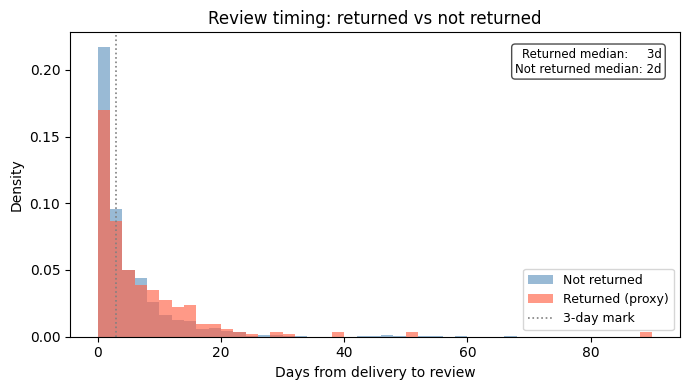

In [7]:
delivered = df[
    df["order_status"].eq("delivered") &
    df["order_delivered_customer_date"].notna() &
    df["review_creation_date"].notna() &
    df["days_to_review"].notna() &
    df["days_to_review"].gt(0)
].copy()
ret     = delivered[delivered["is_return"] == 1]["days_to_review"]
not_ret = delivered[delivered["is_return"] == 0]["days_to_review"]

fig, ax = plt.subplots(figsize=(7, 4))
bins = range(0, 91, 2)
ax.hist(not_ret, bins=bins, density=True, alpha=0.55, label="Not returned", color="steelblue")
ax.hist(ret,     bins=bins, density=True, alpha=0.65, label="Returned (proxy)", color="tomato")
ax.axvline(3, color="gray", linestyle=":", linewidth=1.2, label="3-day mark")
ax.set_xlabel("Days from delivery to review")
ax.set_ylabel("Density")
ax.set_title("Review timing: returned vs not returned")
ax.legend(fontsize=9)
ax.text(0.97, 0.95,
        f"Returned median:     {ret.median():.0f}d\nNot returned median: {not_ret.median():.0f}d",
        transform=ax.transAxes, ha="right", va="top", fontsize=8.5,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}plot3_timing.png", dpi=150)
plt.show()

## PLOT 4 — Order value: returned vs not (box plot)

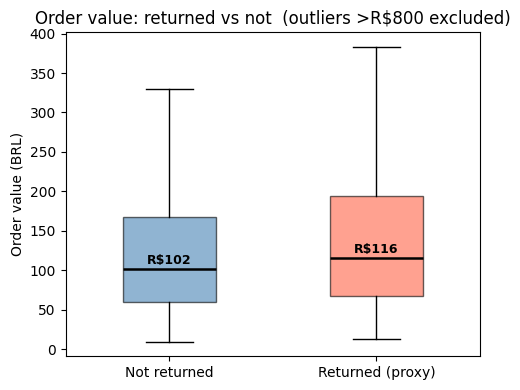

In [8]:
vals = df[
    df["order_status"].eq("delivered") &
    df["total_value"].notna() &
    df["total_value"].lt(800)
].copy()

fig, ax = plt.subplots(figsize=(5, 4))
groups = [vals[vals["is_return"]==0]["total_value"].values,
          vals[vals["is_return"]==1]["total_value"].values]

bp = ax.boxplot(groups, labels=["Not returned", "Returned (proxy)"],
                patch_artist=True, widths=0.45, showfliers=False,
                medianprops=dict(color="black", linewidth=1.8))
bp["boxes"][0].set(facecolor="steelblue", alpha=0.6)
bp["boxes"][1].set(facecolor="tomato",    alpha=0.6)

for i, group in enumerate(groups, 1):
    med = np.median(group)
    ax.text(i, med + 6, f"R${med:.0f}", ha="center", fontsize=9, fontweight="bold")

ax.set_ylabel("Order value (BRL)")
ax.set_title("Order value: returned vs not  (outliers >R$800 excluded)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}plot4_order_value.png", dpi=150)
plt.show()

## PLOT 5 — Return rate by state

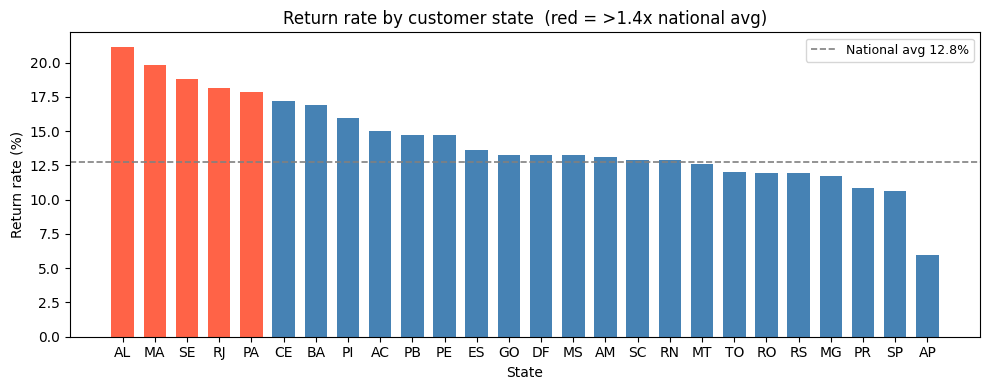

In [9]:
state = (df[df["order_status"] == "delivered"]
    .groupby("customer_state")
    .agg(total=("order_id","count"), returns=("is_return","sum"))
    .query("total >= 50")
    .assign(return_rate=lambda d: d["returns"] / d["total"])
    .sort_values("return_rate", ascending=False)
    .reset_index())

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["tomato" if r > overall_rate * 1.4 else "steelblue"
          for r in state["return_rate"]]
ax.bar(state["customer_state"], state["return_rate"] * 100,
       color=colors, width=0.7)
ax.axhline(overall_rate * 100, color="gray", linestyle="--", linewidth=1.2,
           label=f"National avg {overall_rate*100:.1f}%")
ax.set_xlabel("State")
ax.set_ylabel("Return rate (%)")
ax.set_title("Return rate by customer state  (red = >1.4x national avg)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}plot5_return_by_state.png", dpi=150)
plt.show()

## PLOT 6 — Null counts

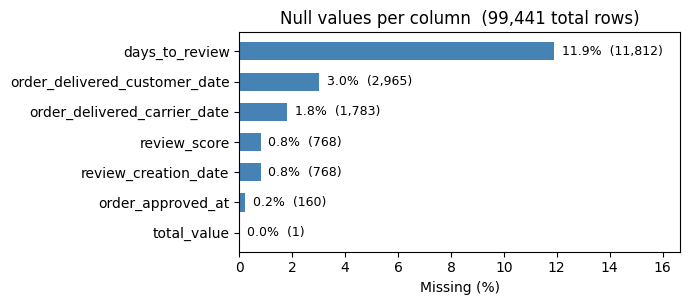

In [10]:
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=True)
pct   = (nulls / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(7, max(3, len(nulls) * 0.45)))

if len(nulls) > 0:
    bars = ax.barh(nulls.index, pct.values, color="steelblue", height=0.6)
    for bar, p, n in zip(bars, pct.values, nulls.values):
        ax.text(p + 0.3, bar.get_y() + bar.get_height()/2,
                f"{p}%  ({n:,})", va="center", fontsize=9)
    ax.set_xlabel("Missing (%)")
    ax.set_xlim(0, pct.max() * 1.4)
else:
    ax.text(0.5, 0.5, "No nulls found.", transform=ax.transAxes,
            ha="center", va="center", fontsize=12)

ax.set_title(f"Null values per column  ({len(df):,} total rows)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}plot6_nulls.png", dpi=150)
plt.show()


##  SUMMARY

In [11]:
print(f"""
{'='*50}
EDA SUMMARY
{'='*50}
Total orders:       {len(df):,}
Delivered:          {(df['order_status']=='delivered').sum():,}
Return proxy:       {df['is_return'].sum():,}  ({df['is_return'].mean()*100:.2f}%)
Unique customers:   {df['customer_unique_id'].nunique():,}
States:             {df['customer_state'].nunique()}
Median order value: R${df['total_value'].median():.2f}

High-risk states (>1.4x avg):
""")
print(state[state["return_rate"] > overall_rate * 1.4][["customer_state","return_rate","total"]].to_string(index=False))


EDA SUMMARY
Total orders:       99,441
Delivered:          96,478
Return proxy:       12,311  (12.38%)
Unique customers:   96,096
States:             27
Median order value: R$105.29

High-risk states (>1.4x avg):

customer_state  return_rate  total
            AL     0.211587    397
            MA     0.198047    717
            SE     0.188060    335
            RJ     0.181862  12350
            PA     0.178647    946
